In [17]:
# Load packages
import dropbox
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import ElasticNetCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

os.chdir("/users/eleves-a/2025/louise.gatty")
os.getcwd()

'/users/eleves-a/2025/louise.gatty'

# 1. Train-test split

In [2]:
# Load main data
df = pd.read_csv("https://www.dropbox.com/scl/fi/snny0t6c5h4zcy23nwtz9/AirQualityData_Imputed_Feature_Engineered.csv?rlkey=hj7nbjuve3cp8ecvxvwbfeh8m&st=vtqbw1l9&dl=1")
df.head()

,Date,ninsee,no2,o3,pm10,Smoothed_no2,Smoothed_no2_L2,Smoothed_no2_L3,Smoothed_o3,Smoothed_o3_L2,...,Eletricity_Total_2017,Electricity_Electricity_2017,GHG_Tertiary_2021,GHG_Agriculture_2021,GHG_Transport_Other_2021,GHG_Trash_2021,GHG_Energy_2021,GHG_Industry_2021,GHG_Residential_2021,GHG_Road_2021
0,2017-01-04,75101,34,13,34,26.350006,23.201945,20.000000,7.779456,7.328373,...,1.969938,2.210248,1.91574,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056
1,2017-01-05,75101,38,17,39,28.391244,26.350006,23.201945,11.285714,7.779456,...,1.969938,2.210248,1.91574,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056
2,2017-01-06,75101,35,13,44,30.955137,28.391244,26.350006,15.123582,11.285714,...,1.969938,2.210248,1.91574,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056
3,2017-01-07,75101,31,9,50,32.034423,30.955137,28.391244,13.697327,15.123582,...,1.969938,2.210248,1.91574,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056
4,2017-01-08,75101,36,7,47,31.758409,32.034423,30.955137,10.542476,13.697327,...,1.969938,2.210248,1.91574,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056


In [3]:
# Load train and test communes
test_communes = pd.read_csv("XCroissants-Predicting-Air-Quality/03. Prediction/00.A Train-Test-Communes/Test-Communes.csv")
train_communes = pd.read_csv("XCroissants-Predicting-Air-Quality/03. Prediction/00.A Train-Test-Communes/Train-Communes.csv")
train_communes.head()

,Commune
0,77415
1,77464
2,77168
3,77533
4,77185


In [4]:
# Merge main data with train and test communes
train_merged = pd.merge(df, train_communes, left_on="ninsee", right_on="Commune", how="right")
test_merged = pd.merge(df, test_communes, left_on="ninsee", right_on="Commune", how="right")
train_merged.head()

,Date,ninsee,no2,o3,pm10,Smoothed_no2,Smoothed_no2_L2,Smoothed_no2_L3,Smoothed_o3,Smoothed_o3_L2,...,Electricity_Electricity_2017,GHG_Tertiary_2021,GHG_Agriculture_2021,GHG_Transport_Other_2021,GHG_Trash_2021,GHG_Energy_2021,GHG_Industry_2021,GHG_Residential_2021,GHG_Road_2021,Commune
0,2017-01-04,77415,17,16,25,11.796488,9.766870,9.000000,9.758413,10.504198,...,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534,77415
1,2017-01-05,77415,16,19,32,12.594571,11.796488,9.766870,12.853007,9.758413,...,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534,77415
2,2017-01-06,77415,16,18,30,13.116876,12.594571,11.796488,15.900701,12.853007,...,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534,77415
3,2017-01-07,77415,17,15,49,13.559072,13.116876,12.594571,16.941538,15.900701,...,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534,77415
4,2017-01-08,77415,21,6,60,14.086821,13.559072,13.116876,15.978919,16.941538,...,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534,77415


In [5]:
# Create working train and test datasets
train_df = train_merged.drop(columns=["Commune"])
test_df = test_merged.drop(columns=["Commune"])

# Delete merged datasets to save memory
del train_merged
del test_merged

train_df.head()

,Date,ninsee,no2,o3,pm10,Smoothed_no2,Smoothed_no2_L2,Smoothed_no2_L3,Smoothed_o3,Smoothed_o3_L2,...,Eletricity_Total_2017,Electricity_Electricity_2017,GHG_Tertiary_2021,GHG_Agriculture_2021,GHG_Transport_Other_2021,GHG_Trash_2021,GHG_Energy_2021,GHG_Industry_2021,GHG_Residential_2021,GHG_Road_2021
0,2017-01-04,77415,17,16,25,11.796488,9.766870,9.000000,9.758413,10.504198,...,-0.27177,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534
1,2017-01-05,77415,16,19,32,12.594571,11.796488,9.766870,12.853007,9.758413,...,-0.27177,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534
2,2017-01-06,77415,16,18,30,13.116876,12.594571,11.796488,15.900701,12.853007,...,-0.27177,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534
3,2017-01-07,77415,17,15,49,13.559072,13.116876,12.594571,16.941538,15.900701,...,-0.27177,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534
4,2017-01-08,77415,21,6,60,14.086821,13.559072,13.116876,15.978919,16.941538,...,-0.27177,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534


In [6]:
# Load machine learning packages
import sklearn as sk
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.impute import SimpleImputer

# 2. Data preprocessing

LinearRegression() does not work with NaN values. So we will create flags for them and impute the median for the computation. This will:
- do the computing on the median value (so that it does not stop),
- adjust the weight of the was_na columns (to understand that when the value was missing, the impact on air quality was maybe different).

In [ ]:
# Drop date variable
train_df = train_df.drop(columns=['Date'])
test_df = test_df.drop(columns=['Date'])

# Flag NaN values
for col in train_df.columns:
    train_df[f'{col}_was_na'] = train_df[col].isna().astype(int)
for col in test_df.columns:
    test_df[f'{col}_was_na'] = test_df[col].isna().astype(int)

# Imputing missing values with median
imputer = SimpleImputer(strategy='median').set_output(transform="pandas")
train_df = imputer.fit_transform(train_df)
test_df = imputer.transform(test_df)

type(train_df)

/tmp/ipykernel_1213234/2633704886.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f'{col}_was_na'] = train_df[col].isna().astype(int)
/tmp/ipykernel_1213234/2633704886.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f'{col}_was_na'] = train_df[col].isna().astype(int)
/tmp/ipykernel_1213234/2633704886.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

pandas.core.frame.DataFrame

In [11]:
# Separate features and target variables (X for features, y for targets)
X_train = train_df.drop(columns=['no2', 'o3', 'pm10'])
y_train_no2 = train_df['no2']
y_train_o3 = train_df['o3']
y_train_pm10 = train_df['pm10']

# Prepare test data
X_test = test_df.drop(columns=['no2', 'o3', 'pm10'])
y_test_no2 = test_df['no2']
y_test_o3 = test_df['o3']
y_test_pm10 = test_df['pm10']

We choose an Elastic Net model as it combines the advantages of the LASSO and Ridge models:
- capable of deleting variables,
- reduce the importance of some variables without dropping them to zero.

It also converges (loss function is convex).

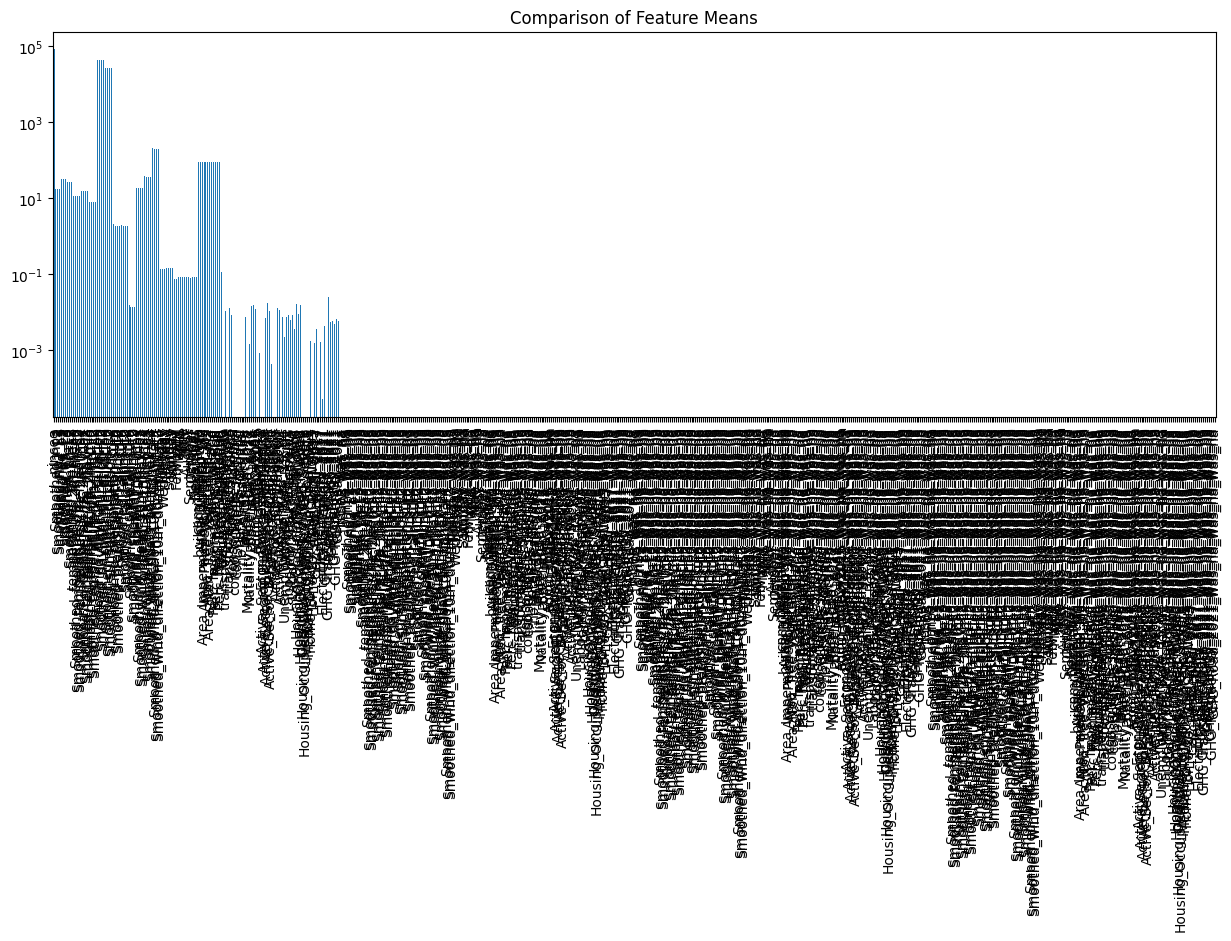

In [12]:
# Plotting the 'mean' of all features to see scale differences
X_train.describe().T['mean'].plot(kind='bar', figsize=(15, 5))
plt.title("Comparison of Feature Means")
plt.yscale('log')
plt.show()

In [13]:
# Count the occurrences of each class in the target variable
counts_no2 = y_train_no2.value_counts()
counts_pm10 = y_train_pm10.value_counts()
counts_o3 = y_train_o3.value_counts()

# NO2: Group the classes with less than 11 samples into 'Other' category
rare_classes_no2 = counts_no2[counts_no2 < 11].index
y_train_no2 = y_train_no2.replace(rare_classes_no2, 'Other')

# PM10: Group the class with less than 11 samples into the 'Other' category
rare_classes_pm10 = counts_pm10[counts_pm10 < 11].index
y_train_pm10 = y_train_pm10.replace(rare_classes_pm10, 'Other')

In [14]:
# Same for the test set
counts_no2_test = y_test_no2.value_counts()
counts_pm10_test = y_test_pm10.value_counts()
counts_o3_test = y_test_o3.value_counts()

# NO2: Group the classes with less than 11 samples into 'Other' category
rare_classes_no2_test = counts_no2_test[counts_no2_test < 11].index
y_test_no2 = y_test_no2.replace(rare_classes_no2_test, 'Other')

# O3: Group the class with less than 8 samples into the 'Other' category
rare_classes_o3_test = counts_o3_test[counts_o3_test < 8].index
y_test_o3 = y_test_o3.replace(rare_classes_o3_test, 'Other')

# PM10: Group the class with less than 7 samples into the 'Other' category
rare_classes_pm10_test = counts_pm10_test[counts_pm10_test < 7].index
y_test_pm10 = y_test_pm10.replace(rare_classes_pm10_test, 'Other')

In [15]:
# Convert the target variable to numeric, coerce errors to NaN, then fill NaN with median
y_train_no2 = pd.to_numeric(y_train_no2, errors='coerce')
y_train_no2 = y_train_no2.fillna(y_train_no2.median())
y_train_o3 = pd.to_numeric(y_train_o3, errors='coerce')
y_train_o3 = y_train_o3.fillna(y_train_o3.median())
y_train_pm10 = pd.to_numeric(y_train_pm10, errors='coerce')
y_train_pm10 = y_train_pm10.fillna(y_train_pm10.median())

# Same for the test set
y_test_no2 = pd.to_numeric(y_test_no2, errors='coerce')
y_test_no2 = y_test_no2.fillna(y_test_no2.median())
y_test_o3 = pd.to_numeric(y_test_o3, errors='coerce')
y_test_o3 = y_test_o3.fillna(y_test_o3.median())
y_test_pm10 = pd.to_numeric(y_test_pm10, errors='coerce')
y_test_pm10 = y_test_pm10.fillna(y_test_pm10.median())

In [18]:
# Separate categorical and numeric columns
categorical_cols = ['ninsee', "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday", "January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
numeric_cols = X_train.columns.difference(categorical_cols)

# Create the transformer: standardize numeric features and target encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', TargetEncoder(target_type='continuous'), categorical_cols)
    ],
    remainder='passthrough'
)

# Integrate into a pipeline with the model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNetCV(l1_ratio=[.1, .5, .9], cv=5, n_alphas=50, n_jobs=-1)) # Using parallel processing
])

# 4. Predictions and Diagnosis

## 4.1. NO2

In [26]:
# Train the pipeline on the training data for NO2
pipeline.fit(X_train, y_train_no2)

KeyboardInterrupt: 

In [ ]:
# Run NO2 prediction using the pipeline
y_pred_no2 = pipeline.predict(X_test)

# Predictions and evaluation for NO2
rmse_no2 = root_mean_squared_error(y_test_no2, y_pred_no2)
r2_no2 = r2_score(y_test_no2, y_pred_no2)

# Print results for NO2
print(f"Elastic Net NO2 – RMSE: {rmse_no2:.2f}, R²: {r2_no2:.2f}, Stdev no2: {y_train_no2.std():.2f}")

Elastic Net NO2 – RMSE: 6.24, R²: 0.53, Stdev no2: 9.33


In [ ]:
output_path = "/users/eleves-a/2025/louise.gatty/XCroissants-Predicting-Air-Quality/03. Prediction/Elastic-Net-Predictions"

# Predictions VS actuals
pd.DataFrame({
    "ninsee"         : test_df["ninsee"].values,
    "actual_no2"    : y_test_no2,
    "predicted_no2" : y_pred_no2,
    "residual"       : y_test_no2 - y_pred_no2,
    "abs_error"      : np.abs(y_test_no2 - y_pred_no2),
}).to_csv(os.path.join(output_path, "Outputs-NO2/predictions_vs_actuals.csv"), index=False)

# Model coefficients
model_en_no2 = pipeline.named_steps['model']
coeffs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_en_no2.coef_
})
intercept = model_en_no2.intercept_
coeffs['abs_coeff'] = coeffs['Coefficient'].abs()
coeffs = coeffs.sort_values(by='abs_coeff', ascending=False).drop(columns=['abs_coeff'])
coeffs.to_csv(os.path.join(output_path, "Outputs-NO2/elastic_net_coeffs.txt"), index=False, sep='\t')

# Features
json.dump(X_train.columns.tolist(), open(os.path.join(output_path, "Outputs-NO2/feature_cols.json"), "w"), indent=2)

# Best parameters
best_params_en = {
    "alpha": float(model_en_no2.alpha_),
    "l1_ratio": float(model_en_no2.l1_ratio_),
    "iterations": int(model_en_no2.n_iter_)
}
json.dump(best_params_en, open(os.path.join(output_path, "Outputs-NO2/elastic_net_best_params.json"), "w"), indent=2)

In [ ]:
# Plot styling
plt.rcParams.update({
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "white",
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.size"         : 11,
})

In [ ]:
def plot_all_diagnostics(model_en_no2, test_df, feature_cols, target_col="no2", save_path="diagnostics.png"):

    y_true = test_df[target_col].values
    y_pred = model_en_no2.predict(test_df[feature_cols])
    residuals = y_true - y_pred

    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    mae  = np.mean(np.abs(residuals))

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(
        f"Elastic Net Regression NO2 — Test set diagnostics (unseen communes)\n"
        f"RMSE: {rmse:.4f}  |  R²: {r2:.4f}  |  MAE: {mae:.4f}",
        fontsize=14, fontweight="bold", y=0.98
    )
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # ── 1. Predicted vs Actual ────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(y_true, y_pred, alpha=0.3, s=8, color="#1a6bb0", rasterized=True)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax1.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax1.set_xlabel("Actual no2")
    ax1.set_ylabel("Predicted no2")
    ax1.set_title("Predicted vs Actual")
    ax1.legend(fontsize=9)

    # ── 2. Residuals vs Predicted ─────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(y_pred, residuals, alpha=0.3, s=8, color="#e07b39", rasterized=True)
    ax2.axhline(0, color="red", linewidth=1.5, linestyle="--")
    ax2.set_xlabel("Predicted no2")
    ax2.set_ylabel("Residual (actual − predicted)")
    ax2.set_title("Residuals vs Predicted")
    # Add a smoothed trend line to spot systematic bias
    sort_idx = np.argsort(y_pred)
    window = max(1, len(y_pred) // 50)
    smooth = pd.Series(residuals[sort_idx]).rolling(window, center=True).mean()
    ax2.plot(y_pred[sort_idx], smooth, color="darkred", linewidth=1.5, label="Trend")
    ax2.legend(fontsize=9)

    # ── 3. Residual distribution ──────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    sns.histplot(residuals, bins=60, kde=True, ax=ax3, color="#5b8a3c", alpha=0.6)
    ax3.axvline(0, color="red", linewidth=1.5, linestyle="--")
    ax3.axvline(residuals.mean(), color="orange", linewidth=1.5,
                linestyle="--", label=f"Mean: {residuals.mean():.3f}")
    ax3.set_xlabel("Residual")
    ax3.set_ylabel("Count")
    ax3.set_title("Residual distribution")
    ax3.legend(fontsize=9)

    # ── 4. Feature importance (top 20) ───────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    importance = pd.Series(
        np.abs(model.coef_),
        index=feature_cols
    ).sort_values(ascending=False).head(20)
    importance.sort_values().plot(kind="barh", ax=ax4, color="#1a6bb0", alpha=0.8)
    ax4.set_xlabel("Coefficient (absolute value)")
    ax4.set_title("Top 20 variables (Elastic Net)")

    # ── 5. Mean absolute error by commune (top 20 worst) ─────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    commune_col = "ninsee"
    commune_mae = (
        test_df.assign(abs_error=np.abs(residuals))
        .groupby(commune_col)["abs_error"]
        .mean()
        .sort_values(ascending=False)
        .head(20)
    )
    commune_mae.sort_values().plot(kind="barh", ax=ax5, color="#e07b39", alpha=0.8)
    ax5.set_xlabel("Mean absolute error")
    ax5.set_title("Top 20 worst communes (MAE)")
    ax5.tick_params(axis="y", labelsize=8)

    # ── 6. Cumulative error distribution (CDF) ────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    abs_errors = np.abs(residuals)
    sorted_errors = np.sort(abs_errors)
    cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
    ax6.plot(sorted_errors, cdf, color="#5b8a3c", linewidth=2)
    # Mark the 50th, 90th, 95th percentiles
    for pct, col in [(0.5, "orange"), (0.9, "red"), (0.95, "darkred")]:
        val = np.quantile(abs_errors, pct)
        ax6.axvline(val, color=col, linestyle="--", linewidth=1.2,
                    label=f"p{int(pct*100)}: {val:.2f}")
    ax6.set_xlabel("Absolute error")
    ax6.set_ylabel("Cumulative proportion of predictions")
    ax6.set_title("Error CDF")
    ax6.legend(fontsize=9)

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved to {save_path}")
    plt.show()
    return fig


# ── Usage ─────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    plot_all_diagnostics(
        model=model_en_no2,
        test_df=test_df_no2,
        feature_cols=X_train.columns,
        target_col="no2",
        save_path=os.path.join(output_path, "Outputs-NO2/no2_diagnostics.png"),
    )

## 4.2. O3

In [ ]:
# Train the pipeline on the training data for O3
pipeline.fit(X_train, y_train_o3)

# Run O3 prediction using the pipeline
y_pred_o3 = pipeline.predict(X_test)

# Predictions and evaluation for O3
rmse_o3 = root_mean_squared_error(y_test_o3, y_pred_o3)
r2_o3 = r2_score(y_test_o3, y_pred_o3)
print(f"Elastic Net O3 – RMSE: {rmse_o3:.2f}, R²: {r2_o3:.2f}, Stdev o3: {y_train_o3.std():.2f}")

Elastic Net O3 – RMSE: 5.29, R²: 0.76, Stdev o3: 10.87


In [ ]:
output_path = "/users/eleves-a/2025/louise.gatty/XCroissants-Predicting-Air-Quality/03. Prediction/Elastic-Net-Predictions"

# Predictions VS actuals
pd.DataFrame({
    "ninsee"         : test_df["ninsee"].values,
    "actual_o3"    : y_test_o3,
    "predicted_o3" : y_pred_o3,
    "residual"       : y_test_o3 - y_pred_o3,
    "abs_error"      : np.abs(y_test_o3 - y_pred_o3),
}).to_csv(os.path.join(output_path, "Outputs-O3/predictions_vs_actuals.csv"), index=False)

# Model coefficients
model_en_o3 = pipeline.named_steps['model']
coeffs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_en_o3.coef_
})
intercept = model_en_o3.intercept_
coeffs['abs_coeff'] = coeffs['Coefficient'].abs()
coeffs = coeffs.sort_values(by='abs_coeff', ascending=False).drop(columns=['abs_coeff'])
coeffs.to_csv(os.path.join(output_path, "Outputs-O3/elastic_net_coeffs.txt"), index=False, sep='\t')

# Features
json.dump(X_train.columns.tolist(), open(os.path.join(output_path, "Outputs-O3/feature_cols.json"), "w"), indent=2)

# Best parameters
best_params_en = {
    "alpha": float(model_en_o3.alpha_),
    "l1_ratio": float(model_en_o3.l1_ratio_),
    "iterations": int(model_en_o3.n_iter_)
}
json.dump(best_params_en, open(os.path.join(output_path, "Outputs-O3/elastic_net_best_params.json"), "w"), indent=2)

## 4.3. PM10

In [ ]:
# Train the pipeline on the training data for PM10
pipeline.fit(X_train, y_train_pm10)

# Run PM10 prediction using the pipeline
y_pred_pm10 = pipeline.predict(X_test)

# Predictions and evaluation for PM10
rmse_pm10 = root_mean_squared_error(y_test_pm10, y_pred_pm10)
r2_pm10 = r2_score(y_test_pm10, y_pred_pm10)
print(f"Elastic Net PM10 – RMSE: {rmse_pm10:.2f}, R²: {r2_pm10:.2f}, Stdev pm10: {y_train_pm10.std():.2f}")

Elastic Net PM10 – RMSE: 7.64, R²: 0.71, Stdev pm10: 14.20


In [ ]:
output_path = "/users/eleves-a/2025/louise.gatty/XCroissants-Predicting-Air-Quality/03. Prediction/Elastic-Net-Predictions"

# Predictions VS actuals
pd.DataFrame({
    "ninsee"         : test_df["ninsee"].values,
    "actual_pm10"    : y_test_pm10,
    "predicted_pm10" : y_pred_pm10,
    "residual"       : y_test_pm10 - y_pred_pm10,
    "abs_error"      : np.abs(y_test_pm10 - y_pred_pm10),
}).to_csv(os.path.join(output_path, "Outputs-PM10/predictions_vs_actuals.csv"), index=False)
# Model coefficients
model_en_pm10 = pipeline.named_steps['model']
coeffs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_en_pm10.coef_
})
intercept = model_en_pm10.intercept_
coeffs['abs_coeff'] = coeffs['Coefficient'].abs()
coeffs = coeffs.sort_values(by='abs_coeff', ascending=False).drop(columns=['abs_coeff'])
coeffs.to_csv(os.path.join(output_path, "Outputs-PM10/elastic_net_coeffs.txt"), index=False, sep='\t')

# Features
json.dump(X_train.columns.tolist(), open(os.path.join(output_path, "Outputs-PM10/feature_cols.json"), "w"), indent=2)

# Best parameters
best_params_en = {
    "alpha": float(model_en_pm10.alpha_),
    "l1_ratio": float(model_en_pm10.l1_ratio_),
    "iterations": int(model_en_pm10.n_iter_)
}
json.dump(best_params_en, open(os.path.join(output_path, "Outputs-PM10/elastic_net_best_params.json"), "w"), indent=2)